<a href="https://colab.research.google.com/github/vitalinamysiv/restaurant-visitor-forecasting/blob/main/notebooks/02_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Моделирование

## Цель

Построить модель для прогнозирования количества посетителей ресторана на следующие 7 дней.

## Этапы работы

1. Генерация признаков:
   - календарные признаки;
   - лаговые признаки;
   - скользящие статистики.

2. Разделение данных:
   - обучение на исторических данных;
   - проверка качества на будущем периоде.

3. Построение бейзлайн-модели.

4. Обучение и сравнение ML-моделей.

## Целевая переменная

`guests` — количество посетителей ресторана за день.

In [11]:
!git clone https://github.com/vitalinamysiv/restaurant-visitor-forecasting.git

Cloning into 'restaurant-visitor-forecasting'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 83 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 230.94 KiB | 1.86 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [12]:
%cd restaurant-visitor-forecasting

/content/restaurant-visitor-forecasting/restaurant-visitor-forecasting


In [13]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
!ln -s /content/drive/MyDrive/restaurant_forecasting/data/raw/train.csv data/raw/train.csv
!ln -s /content/drive/MyDrive/restaurant_forecasting/data/raw/store.csv data/raw/store.csv

In [15]:
!python src/create_dataset.py

Загрузка данных...
Размер исходных данных: (1017209, 5)
Готово!
Размер обработанных данных: (844392, 4)
Сохранено: data/processed/restaurant_daily.csv


In [16]:
import pandas as pd

df = pd.read_csv(
    "data/processed/restaurant_daily.csv",
    parse_dates=["date"]
)

df.head()

,restaurant_id,date,revenue,guests
0,1,2013-01-02,5530,668
1,1,2013-01-03,4327,578
2,1,2013-01-04,4486,619
3,1,2013-01-05,4997,635
4,1,2013-01-07,7176,785


In [17]:
from src.features import make_features

In [18]:
df_features = make_features(df)

df_features.head()

,restaurant_id,date,revenue,guests,day_of_week,month,day_of_month,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_28
0,1,2013-01-02,5530,668,2,1,2,0,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-03,4327,578,3,1,3,0,668.0,NaN,NaN,NaN,NaN
2,1,2013-01-04,4486,619,4,1,4,0,578.0,NaN,NaN,NaN,NaN
3,1,2013-01-05,4997,635,5,1,5,1,619.0,NaN,NaN,NaN,NaN
4,1,2013-01-07,7176,785,0,1,7,0,635.0,NaN,NaN,NaN,NaN


In [19]:
df_features = df_features.dropna()

df_features.shape

(813172, 13)

In [20]:
from src.validation import time_split

In [21]:
train, valid = time_split(
    df_features,
    valid_weeks=6
)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [23]:
baseline_pred = valid["lag_7"]

In [24]:
mae_baseline = mean_absolute_error(
    valid["guests"],
    baseline_pred
)

mape_baseline = mean_absolute_percentage_error(
    valid["guests"],
    baseline_pred
)


print("MAE:", mae_baseline)
print("MAPE:", mape_baseline)

MAE: 163.4002035648677
MAPE: 0.24907383917556267


## Бейзлайн-модель

В качестве базового решения используется сезонный наивный прогноз.

Предполагается, что количество посетителей в текущий день будет равно количеству посетителей в этот же день недели неделю назад.

Такой подход позволяет учесть недельную сезонность посещаемости и использовать его как точку сравнения для более сложных моделей.

Результаты:

- MAE: 163.4
- MAPE: 24.9%

In [25]:
features = [
    "restaurant_id",
    "revenue",
    "day_of_week",
    "month",
    "day_of_month",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_28"
]


X_train = train[features]

y_train = train["guests"]


X_valid = valid[features]

y_valid = valid["guests"]

In [26]:
print(X_train.shape)
print(X_valid.shape)

(772890, 11)
(40282, 11)


## Линейная модель Ridge

В качестве первой ML-модели используется Ridge Regression.

Она служит простым ориентиром для сравнения с более сложными алгоритмами.

In [27]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [28]:
ridge = Ridge(
    alpha=1.0
)

ridge.fit(
    X_train,
    y_train
)

Ridge()

In [29]:
ridge_pred = ridge.predict(
    X_valid
)

In [30]:
ridge_mae = mean_absolute_error(
    y_valid,
    ridge_pred
)

ridge_mape = mean_absolute_percentage_error(
    y_valid,
    ridge_pred
)


print(
    "Ridge MAE:",
    ridge_mae
)

print(
    "Ridge MAPE:",
    ridge_mape
)

Ridge MAE: 69.69467548737025
Ridge MAPE: 0.1031080913181904


## Результаты Ridge Regression

Линейная модель Ridge показала существенное улучшение относительно сезонного бейзлайна.

Baseline:
- MAE: 163.4
- MAPE: 24.9%

Ridge:
- MAE: 69.7
- MAPE: 10.3%

Использование календарных признаков, лагов и скользящих статистик позволило значительно повысить качество прогноза.

In [31]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [32]:
from src.model import train_model
catboost_model = train_model(
    X_train,
    y_train
)

0:	learn: 248.7634782	total: 207ms	remaining: 1m 43s
100:	learn: 63.6570148	total: 16.2s	remaining: 1m 3s
200:	learn: 58.0101670	total: 27s	remaining: 40.2s
300:	learn: 55.2507052	total: 38s	remaining: 25.1s
400:	learn: 53.2032807	total: 49s	remaining: 12.1s
499:	learn: 51.7068605	total: 59.2s	remaining: 0us


In [33]:
catboost_pred = catboost_model.predict(
    X_valid
)

In [34]:
catboost_mae = mean_absolute_error(
    y_valid,
    catboost_pred
)


catboost_mape = mean_absolute_percentage_error(
    y_valid,
    catboost_pred
)


print(
    "CatBoost MAE:",
    catboost_mae
)

print(
    "CatBoost MAPE:",
    catboost_mape
)

CatBoost MAE: 49.82219543125655
CatBoost MAPE: 0.0712639912474441


## Сравнение моделей

Были протестированы три подхода:

1. Seasonal baseline:
   прогноз количества гостей равен значению за аналогичный день недели неделю назад.

2. Ridge Regression:
   линейная модель, использующая календарные и временные признаки.

3. CatBoost:
   градиентный бустинг по деревьям решений.


| Модель | MAE | MAPE |
|---|---:|---:|
| Baseline (lag_7) | 163.4 | 24.9% |
| Ridge Regression | 69.7 | 10.3% |
| CatBoost | 49.8 | 7.1% |


CatBoost показал лучшее качество на отложенном временном периоде.
Использование лаговых признаков, календарных факторов и скользящих статистик позволило значительно улучшить прогноз относительно базового решения.

In [35]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": catboost_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
10,rolling_mean_28,35.950002
1,revenue,27.248866
6,lag_1,13.834027
9,rolling_mean_7,8.153883
2,day_of_week,5.385960
0,restaurant_id,2.148630
3,month,1.676730
8,lag_14,1.604428
5,is_weekend,1.453305
7,lag_7,1.275181


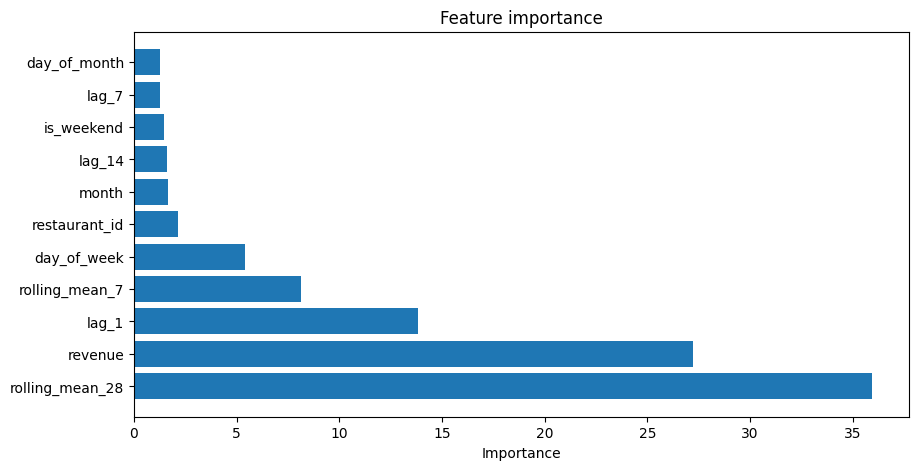

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.title(
    "Feature importance"
)

plt.xlabel(
    "Importance"
)

plt.show()

In [39]:
from src.model import save_model

save_model(
    catboost_model
)